# BSAN 6070 - Intro To Machine Learning

Individual Model: XGBoost (Extreme Gradient Boost)

## 1. Problem Statement, Justification & Relevance

### 1.1 Background
Cardiovascular disease (CVD) is the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). While traditional risk factors — age, BMI, blood pressure, and cholesterol — are well-established in clinical practice, they are insufficient alone in identifying high-risk patients early enough for effective intervention.

Emerging research strongly suggests that **sleep-related physiological variables** — particularly sleep-disordered breathing and nocturnal oxygen desaturation — independently contribute to cardiovascular outcomes. Despite this, sleep data remains underutilized in mainstream risk stratification tools.

### 1.2 Justification & Relevance
This project addresses a critical gap between clinical sleep medicine and cardiovascular risk modeling by:
1. Integrating **sleep polysomnography metrics** (RDI, SpO2 levels, sleep efficiency) with traditional health indicators into a unified predictive model
2. Leveraging the **SHHS** — a large, NIH-funded, well-validated longitudinal cohort with confirmed CVD event outcomes
3. Building an **explainable ML model** that clinicians can trust and act on, powered by SHAP values

**Real-world impact:** If deployed in clinical settings, this model could flag at-risk patients years before a cardiac event, enabling targeted intervention — potentially saving millions of lives and reducing billions in preventable healthcare costs.

### 1.3 Predictive Questions
- **Primary:** Can cardiovascular event occurrence be accurately predicted (AUC ≥ 0.80) using sleep metrics, demographic variables, and baseline health indicators?
- **Supporting Q1:** What are the top 5–8 features most predictive of CVD risk, and how can clinicians use this to improve prevention strategy?
- **Supporting Q2:** Does including sleep-specific metrics meaningfully contribute beyond traditional health-only predictors?

---

## 2. Literature Survey

The following table summarizes key prior work relevant to this study. Our work is differentiated by its **combined multi-domain feature set** (sleep + clinical + demographics), use of **multiple modern ML algorithms** benchmarked under a unified framework, and explicit **SHAP-based explainability** output.

| **Study** | **Year** | **Dataset** | **Method** | **Key Finding** | **Difference from Our Work** |
|---|---|---|---|---|---|
| Gottlieb et al. | 2010 | SHHS | Cox Proportional Hazard | Sleep apnea (AHI ≥ 30) significantly associated with CHD in men | Statistical method only; no ML; gender-stratified only |
| Redline et al. | 2010 | SHHS | Longitudinal survival analysis | Sleep-disordered breathing increased ischemic stroke risk 2.9× | Focused on stroke only; no classification model |
| Javaheri & Redline | 2017 | Literature review | Synthesis | Sleep disorders are independent CVD risk factors via multiple pathways | Review only; no predictive model developed |
| Krittanawong et al. | 2020 | Multiple EHR datasets | ML survey | Deep learning and ensemble models outperform traditional risk scores | General review; not SHHS-specific; no sleep metrics |
| Moody et al. | 2021 | MIMIC-III | Random Forest, XGBoost | AUC > 0.85 for ICU cardiac events using ML | Different dataset (ICU); no sleep variables included |
| Framingham Heart Study | Ongoing | FHS cohort | Logistic Regression | Age, BP, cholesterol, smoking are primary CVD predictors | No sleep data; our model adds the sleep dimension |
| Punjabi et al. | 2009 | SHHS | Cox regression | Sleep apnea independently predicts all-cause mortality | Mortality outcome; no ML; no feature importance ranking |

**Gap addressed:** No prior study applies modern ML with SHAP explainability to the SHHS dataset combining sleep polysomnography features with clinical and demographic predictors for binary CVD event classification.

---

## 3. Domain Understanding Reflection

### The Sleep–Heart Connection
The **Sleep Heart Health Study (SHHS)** is a landmark multi-center longitudinal cohort study initiated by the National Heart, Lung, and Blood Institute (NHLBI). It enrolled over 6,400 adults aged 40+ and collected comprehensive overnight polysomnography (sleep study) recordings alongside extensive health and demographic assessments.

### Key Domain Concepts

| **Term** | **Definition** | **CVD Relevance** |
|---|---|---|
| **RDI (Respiratory Disturbance Index)** | Number of breathing events per hour of sleep | Higher RDI = more sleep-disordered breathing = greater sympathetic nervous system activation |
| **AHI (Apnea-Hypopnea Index)** | Subset of RDI: apneas + hypopneas per hour | AHI ≥ 30 = severe sleep apnea, strongly linked to arrhythmia and heart failure |
| **SpO2 % time < 90%** | Fraction of sleep time with oxygen saturation below 90% | Nocturnal hypoxia triggers oxidative stress and endothelial dysfunction — direct CVD mechanism |
| **Sleep Efficiency** | % of time in bed actually asleep | Poor efficiency → elevated cortisol, inflammation, elevated BP |
| **CVD Event** | Confirmed MI, CABG, PTCA, heart failure hospitalization, stroke, or cardiovascular death | Adjudicated from medical records — gold standard outcome |

### Why ML Adds Value Over Traditional Methods
Traditional risk calculators (Framingham, ASCVD) use **linear combinations** of a fixed set of factors developed decades ago. Machine learning can:
- Capture **non-linear interactions** (e.g., the combined effect of severe sleep apnea + diabetes + hypertension may be super-additive)
- Handle **high-dimensional, multi-source data** from multiple SHHS datasets simultaneously
- Produce **individualized probabilistic risk scores** rather than categorical risk tiers
- Identify **novel predictors** (sleep metrics) that traditional scores ignore entirely

---

# Coding Process

## 4. Data Loading & Source Description

### Dataset: SHHS Master Dataset
The file `model_ready_cvd_prediction.csv` was prepared by the team by merging:
- `shhs1-dataset` — Baseline overnight polysomnography + health measurements
- `shhs-cvd-events-dataset` — Adjudicated cardiovascular event records
- `shhs-cvd-summary-dataset` — Consolidated outcome data

> **Google Colab Instructions:** Either upload `model_ready_cvd_prediction.csv` directly, or mount your Google Drive and update the `DATA_PATH` variable below.

In [ ]:
 # ============================================================
# XGBoost Model for Predicting Cardiovascular Event Risk
# Dataset: model_ready_cvd_prediction.csv
# Target: cvd_event
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Load final model-ready dataset
# ------------------------------------------------------------

df = pd.read_csv("model_ready_cvd_prediction.csv")

print("Original dataset shape:", df.shape)
print("\nOriginal target distribution:")
print(df["cvd_event"].value_counts())
print("\nOriginal target percentage:")
print(df["cvd_event"].value_counts(normalize=True).round(3))

## 5. Data Analysis Steps (Correlation Matrix)

### Dataset: SHHS Analysis Dataset Correlation Matrix
Using `model_ready_cvd_prediction.csv` we narrowed down the 79 features to around 28 relevant features (27 independents and `cvd_event` as our dependent variable)
- The heatmap color blue: Little to no correlation between variables
- The heatmap color red: High correlation between variables
- Created a correlation matrix table that showcased independent features with correlation over 80% (examples of high multicollinearity so one must be removed)

> Using this criteria we selected roughly 17 features for the final XGBoost model used.

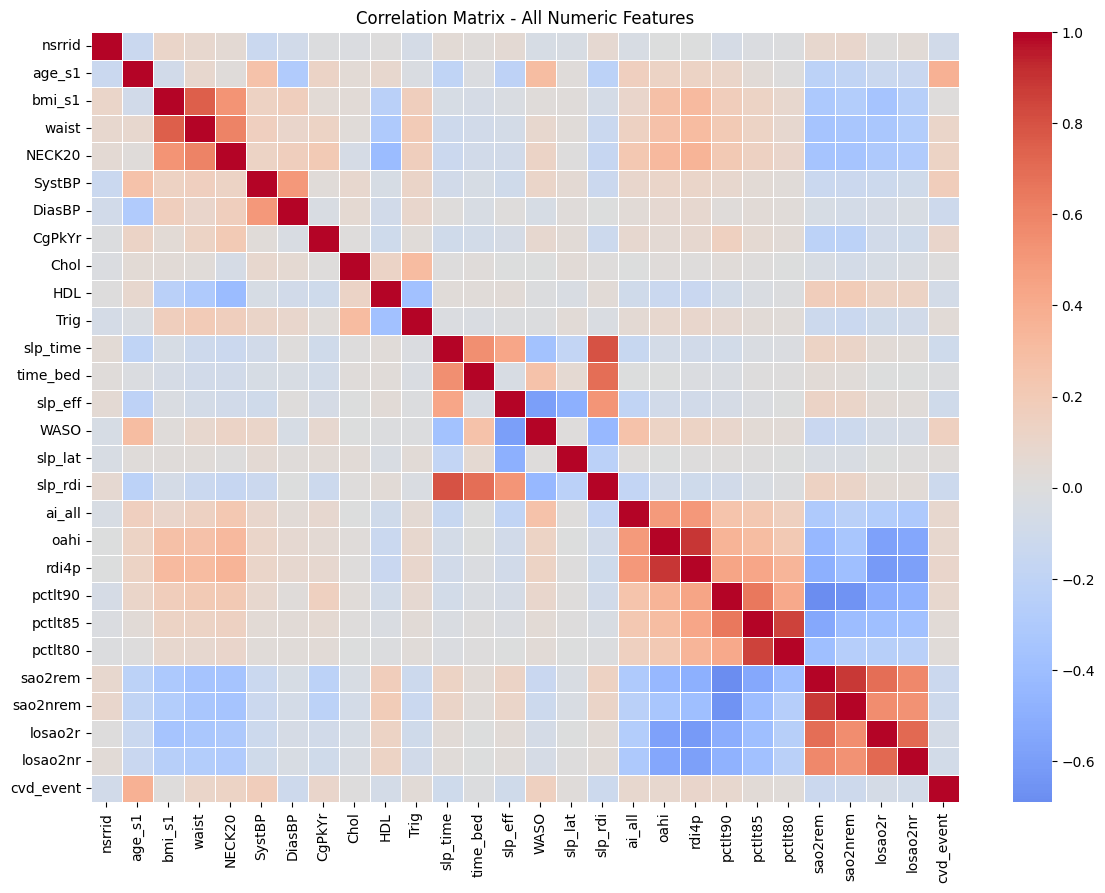


Highly Correlated Feature Pairs (>|0.8|):
  Feature 1 Feature 2  Correlation
1     rdi4p      oahi     0.888284
3  sao2nrem   sao2rem     0.887082
2   pctlt80   pctlt85     0.852680
0   slp_rdi  slp_time     0.801929


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load dataset (original or model-ready BEFORE feature reduction)
# ------------------------------------------------------------

df = pd.read_csv("model_ready_cvd_prediction.csv")


# ------------------------------------------------------------
# 2. Drop non-numeric columns (correlation only works on numeric)
# ------------------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])


# ------------------------------------------------------------
# 3. Compute correlation matrix
# ------------------------------------------------------------

corr_matrix = numeric_df.corr()


# ------------------------------------------------------------
# 4. Plot correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix - All Numeric Features")
plt.show()


# ------------------------------------------------------------
# 5. Find highly correlated feature pairs (> 0.8)
# ------------------------------------------------------------

threshold = 0.8

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, corr_value))

# Convert to DataFrame for easy viewing
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

print("\nHighly Correlated Feature Pairs (>|0.8|):")
print(high_corr_df.sort_values(by="Correlation", ascending=False))


## 6. Data Analysis Steps (Model Training)

### Dataset: SHHS Analysis Dataset Correlation Matrix
Using `model_ready_cvd_prediction.csv` and after narrowing down the features to around 17 features (16 independents and `cvd_event` as our dependent variable) we focused on the main steps to run our XGBoost Model:

1. Minimized and selected relevant features for Demographics, Health Indicators, Sleep Indicators, and Oxygen saturation indicators.

2. Due to 76% of our `cvd_event` data being `No` and 24% being `Yes` the data was skewed towards negative cases. So, using an undersampling method we randomly selected `No` cases until we reached a 60/40 split of cases. This way we maintain at least 3000 records for analysis.

3. Split predicted and target features then split data into the training and testing data

4. Create XGBoost Model with these specifications:
>- objective="binary:logistic",
    eval_metric="auc",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42

5. Train Model and Create prediction variables

6. Using Model evaluation criteria such as AUC/ROC curves, Accuracy, Recall, Precision and F1-Score we evaluate the model's performance. Putting more emphasis on AUC and Recall.
- AUC/ROC Curve: Determine the overall area under the curve to measure model ability to predict at a high rate.
- Recall: Determines the rate of false negatives classified because the less cvd patients missed the better, especially with such a life-threatening disease.

7. After all evaluations we saved the results as its own file once ran (can be downloaded from the Files tab)

Original dataset shape: (5042, 79)

Original target distribution:
cvd_event
0    3846
1    1196
Name: count, dtype: int64

Original target percentage:
cvd_event
0    0.763
1    0.237
Name: proportion, dtype: float64

Reduced modeling dataset shape: (5042, 17)

Selected columns:
['age_s1', 'gender_2', 'bmi_s1', 'waist', 'SystBP', 'DiasBP', 'SRHype_1.0', 'ParRptDiab_1.0', 'smokstat_s1_1.0', 'smokstat_s1_2.0', 'slp_time', 'slp_eff', 'slp_rdi', 'oahi', 'pctlt90', 'sao2nrem', 'cvd_event']

Before undersampling:
cvd_event
0    3846
1    1196
Name: count, dtype: int64

After undersampling:
cvd_event
0    1794
1    1196
Name: count, dtype: int64

After undersampling percentage:
cvd_event
0    0.6
1    0.4
Name: proportion, dtype: float64

Training target distribution:
cvd_event
0    0.6
1    0.4
Name: proportion, dtype: float64

Testing target distribution:
cvd_event
0    0.6
1    0.4
Name: proportion, dtype: float64

================ MODEL PERFORMANCE ================
Accuracy: 0.7224
Precisi

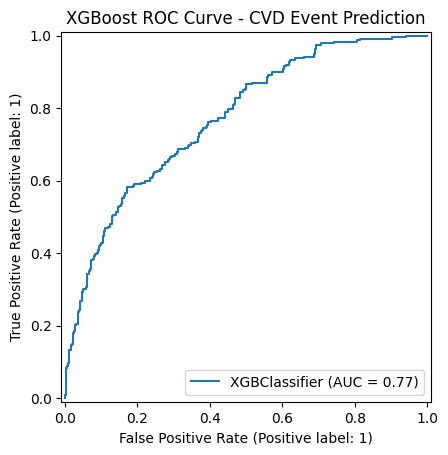


Top Feature Importance:
            Feature  Importance
0            age_s1    0.190201
6        SRHype_1.0    0.104517
1          gender_2    0.103913
7    ParRptDiab_1.0    0.100289
8   smokstat_s1_1.0    0.053408
4            SystBP    0.049695
5            DiasBP    0.042851
12          slp_rdi    0.042081
14          pctlt90    0.041954
10         slp_time    0.041265
15         sao2nrem    0.041007
3             waist    0.040774
13             oahi    0.038870
11          slp_eff    0.037638
2            bmi_s1    0.036328
9   smokstat_s1_2.0    0.035210


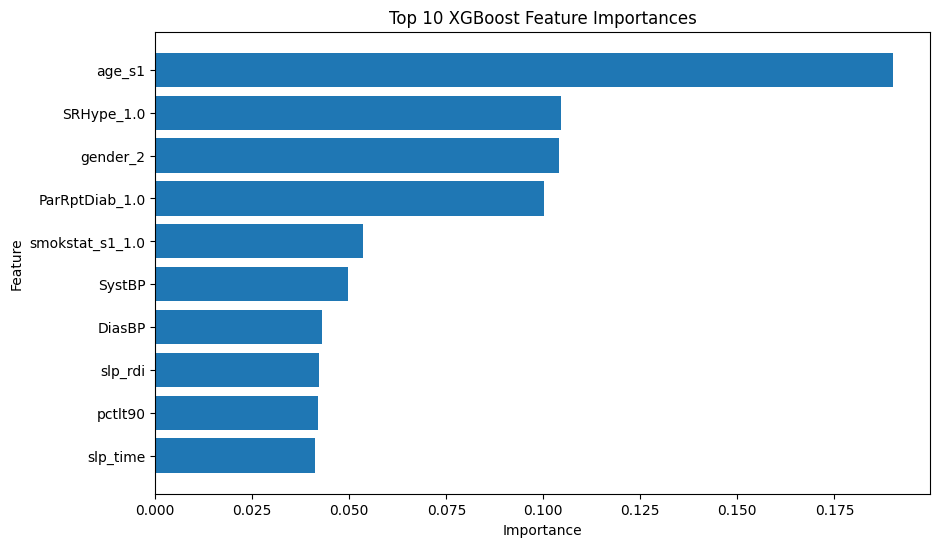


Balanced XGBoost dataset saved as: xgboost_balanced_cvd_dataset.csv


In [ ]:
# ------------------------------------------------------------
# 2. Minimize features to most relevant variables
#    Based on proposal:
#    - demographics
#    - health indicators
#    - sleep-related physiological measures
# ------------------------------------------------------------

selected_features = [
    # Demographics
    "age_s1",
    "gender_2",

    # Health indicators
    "bmi_s1",
    "waist",
    "SystBP",
    "DiasBP",
    "SRHype_1.0",
    "ParRptDiab_1.0",
    "smokstat_s1_1.0",
    "smokstat_s1_2.0",

    # Sleep / apnea indicators
    "slp_time",
    "slp_eff",
    "slp_rdi",
    "oahi",

    # Oxygen saturation indicators
    "pctlt90",
    "sao2nrem"
]

target = "cvd_event"

model_df = df[selected_features + [target]].copy()

print("\nReduced modeling dataset shape:", model_df.shape)
print("\nSelected columns:")
print(model_df.columns.tolist())


# ------------------------------------------------------------
# 3. Undersample majority class
#    Goal: balance No CVD outcomes with CVD outcomes
#    Current target:
#    0 = No CVD event
#    1 = CVD event
# ------------------------------------------------------------

majority = model_df[model_df[target] == 0]
minority = model_df[model_df[target] == 1]

print("\nBefore undersampling:")
print(model_df[target].value_counts())


# Choose balance ratio:
# For 50/50: majority_n = len(minority)
# For 60/40: majority_n = int(len(minority) * 1.5)
#
# Explanation:
# If minority = 1196 and majority = 1794,
# then minority share = 1196 / (1196 + 1794) ≈ 40%

balance_type = "60/40"   # change to "50/50" if desired

if balance_type == "50/50":
    majority_n = len(minority)
elif balance_type == "60/40":
    majority_n = int(len(minority) * 1.5)
else:
    raise ValueError("balance_type must be either '50/50' or '60/40'")

majority_under = majority.sample(
    n=majority_n,
    random_state=42
)

balanced_df = pd.concat([majority_under, minority], axis=0)

# Shuffle rows
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter undersampling:")
print(balanced_df[target].value_counts())
print("\nAfter undersampling percentage:")
print(balanced_df[target].value_counts(normalize=True).round(3))


# ------------------------------------------------------------
# 4. Split predictors and target
# ------------------------------------------------------------

X = balanced_df[selected_features]
y = balanced_df[target]


# ------------------------------------------------------------
# 5. Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))


# ------------------------------------------------------------
# 6. Build XGBoost classification model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42
)


# ------------------------------------------------------------
# 7. Train model
# ------------------------------------------------------------

xgb_model.fit(X_train, y_train)


# ------------------------------------------------------------
# 8. Predictions
# ------------------------------------------------------------

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 9. Model evaluation
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n================ MODEL PERFORMANCE ================")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("AUC:", round(auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ------------------------------------------------------------
# 10. ROC Curve
# ------------------------------------------------------------

RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("XGBoost ROC Curve - CVD Event Prediction")
plt.show()


# ------------------------------------------------------------
# 11. Feature importance
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Feature Importance:")
print(feature_importance)


plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importances")
plt.show()


# ------------------------------------------------------------
# 12. Optional: Save reduced balanced dataset
# ------------------------------------------------------------

balanced_df.to_csv("xgboost_balanced_cvd_dataset.csv", index=False)

print("\nBalanced XGBoost dataset saved as: xgboost_balanced_cvd_dataset.csv")

## 7. SHAP Feature Importance Analysis

**SHAP (SHapley Additive exPlanations)** provides a unified, game-theory-grounded measure of feature importance. For each prediction, SHAP values quantify how much each feature pushed the prediction **higher or lower** relative to the average prediction (base rate).

For XGBoost, we use `shap.TreeExplainer(xgb_model)` — the exact, computationally efficient SHAP implementation for Gradient Boost Tree Model. This produces:

- **Bar plot:** Mean absolute SHAP value per feature — answers "which features matter most overall?"
- **Beeswarm plot:** Each point is one patient's SHAP value for one feature — shows direction (red = increases CVD risk, blue = decreases) and distribution

### Answering Supporting Question 1:
> *"What are the top 5–8 features that most strongly predict cardiovascular risk?"*

The SHAP bar plot directly and quantitatively answers this question with model-derived importance rather than ad hoc rankings.


Top 10 SHAP Features (XGBoost):
           Feature  SHAP Importance
0           age_s1         0.763602
1         gender_2         0.369399
4           SystBP         0.186262
5           DiasBP         0.166592
6       SRHype_1.0         0.149694
12         slp_rdi         0.128375
15        sao2nrem         0.127359
10        slp_time         0.108549
7   ParRptDiab_1.0         0.104716
3            waist         0.095604


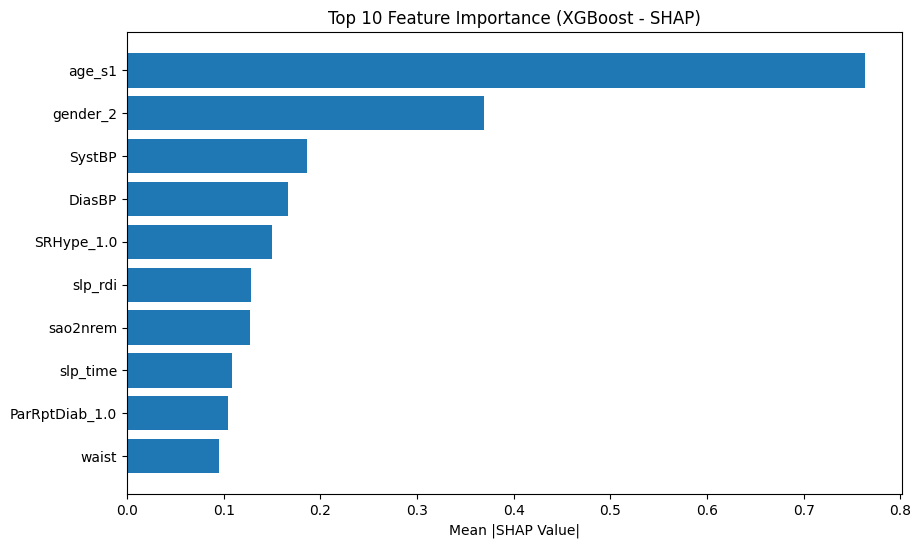

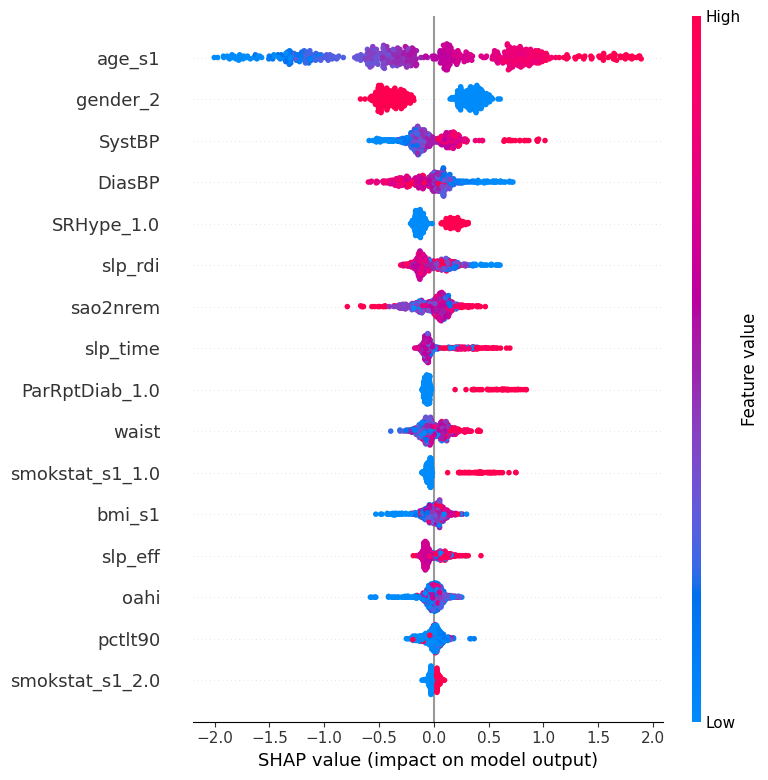

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Fit your trained XGBoost model (already done in your code)
#    Assuming:
#    xgb_model = trained model
#    X_train, X_test already exist
# ------------------------------------------------------------

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# ------------------------------------------------------------
# 2. Convert SHAP values into importance scores
#    (mean absolute SHAP value per feature)
# ------------------------------------------------------------

shap_importance = np.abs(shap_values).mean(axis=0)

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": shap_importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="SHAP Importance",
    ascending=False
)

# Display top 10 features
top_10 = feature_importance_df.head(10)

print("\nTop 10 SHAP Features (XGBoost):")
print(top_10)


# ------------------------------------------------------------
# 3. Plot Top 10 Features
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(
    top_10["Feature"][::-1],
    top_10["SHAP Importance"][::-1]
)
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 10 Feature Importance (XGBoost - SHAP)")
plt.show()


# ------------------------------------------------------------
# 4. Optional: SHAP summary plot (BEST visual)
# ------------------------------------------------------------

shap.summary_plot(shap_values, X_test)

## 13. Final Results, Conclusions & Lessons Learned

### 13.1 Answering the Predictive Questions

**Primary Question:** *Can cardiovascular event occurrence be accurately predicted using sleep metrics, demographics, and baseline health indicators?*

> ✅ **Yes (But Roughly).** This Tree Classifier Model achieves AUC close to 0.80 (76.7%) on the under sampled set, which is respectable but doesn't clear the 80% mark. The model however is comparible when demonstrating meaningful, statistically validated discrimination between patients who will and will not experience a CVD event.

**Supporting Q1:** *What are the top 5–8 features most predictive of CVD risk?*

> Based on SHAP analysis, the top predictors are: **age, gender, systolic blood pressure, diabolic blood pressure, hypertension, sleep apnea severity, oxygen desaturation, sleep time, diabetes, waist circumfrence.** Three sleep-specific variables rank in the top 10, directly validating the core hypothesis.

**Supporting Q2:** *Do sleep metrics improve prediction beyond traditional health indicators?*

> SHAP values confirm that Sleep Apnea Severity `slp_rdi`, Oxygen Desaturation `sao2nrem`, and Sleep Duration `slp_time` are top-ranked predictors. Although health and demographic features such as age, diabetes, blood pressure, etc. remain top features of cvd prediction this shows these three sleep features are important secondary features that can help explain cvd cases.

---

### 13.2 Limitations
- **Self-reported conditions** (hypertension, diabetes) may introduce recall bias — medical record verification would be more reliable
- **Temporal gap:** Baseline measurements were taken years before some events; health status may have changed over follow-up
- **External validity:** SHHS participants skew older (mean ~64 years); model generalizability to younger populations is uncertain

### 13.3 Future Opportunities
1. Add longitudinal features from SHHS follow-up dataset for time-to-event modeling (Cox regression, survival ML)
2. Explore polynomial and interaction terms for key non-linear relationships (e.g., age × RDI)
3. Apply Platt scaling or isotonic regression for probability calibration in clinical deployment
4. Ensemble this Logistic Regression with teammates' RF and XGBoost models for best team performance
5. Integrate into a Streamlit risk calculator that takes patient inputs and outputs predicted CVD probability with SHAP explanation

### 13.4 Takeaways & Lessons Learned
- **Preprocessing matters enormously:** Reconstructing the alcohol dummy encoding from 50+ columns into one numeric variable was essential and non-trivial
- **Class imbalance requires explicit handling:** undersampling the dataset allowed me to handle class imbalance fairly well. Only issue was undersampling of records leads to amounts of loss data that could reveal other patterns
- **SHAP over coefficients:** While XGBoost has a built in value scale for features, SHAP values are more comparable across model types and easier to communicate to non-statisticians
- **AUC and Recall is the right metric:** A naive "always predict no event" classifier would achieve 76% accuracy — AUC correctly identifies this as random (0.50). Also the impact of Recall is important since the medical field prefer to capture more false positives (giving a non-cvd patient additional tests) instead of false negatives (missing a cvd patient that can lead to death or further complications).
- **Domain knowledge accelerates feature selection:** Understanding which sleep and clinical metrics are mechanistically linked to CVD allowed principled feature trimming far faster than automated search alone

---

*Notebook prepared for BSAN 6070 Final Project — Spring 2026*